# **Proyecto: Reconocer Semáforos en Rojo**

## **Introducción:** El objetivo de este modelo es desarrollar una red neuronal artificial del tipo Perceptrón Multicapa (MLP) capaz de clasificar imágenes de semáforos en cuatro categorías: Rojo, Amarillo, Verde y Fondo/Background (imágenes de calles, cielos o señales que no son semáforos, para evitar que el modelo "adivine" un color cuando no hay nada presente).

## **Paso 1: Importación de Librerías**

> En esta sección cargamos las herramientas necesarias para construir, entrenar y evaluar nuestro modelo.

In [ ]:
# Importación de librerías fundamentales
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing import image
from google.colab import files
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn as sns

# Herramientas de evaluación y métricas detalladas
from sklearn.metrics import classification_report, confusion_matrix

print("Entorno preparado. Versión de TensorFlow:", tf.__version__)

Entorno preparado. Versión de TensorFlow: 2.19.0


### **Documentación Técnica de las Librerías**

- TensorFlow & Keras: Framework principal para la construcción de redes neuronales profundas. Se utiliza el módulo layers para definir la arquitectura MLP y image para el preprocesamiento de inferencia externa.

- Scikit-learn (Metrics): Se seleccionó específicamente para la fase de auditoría del modelo. classification_report permite una visión granular del desempeño por clase (Rojo vs Fondo), mientras que confusion_matrix facilita la identificación de sesgos visuales.

- Seaborn & Matplotlib: Librerías de visualización esenciales para convertir los datos de entrenamiento y las matrices de error en información interpretable para la toma de decisiones.

- Numpy: Fundamental para la transformación de imágenes en tensores numéricos escalados, permitiendo las operaciones matemáticas de la red.

## **Paso 2: Carga y Preprocesamiento de Datos**

> En esta etapa preparamos las imágenes reales de semáforos. En este caso, se utiliza un dataset subido directamente al entorno de ejecución de Google Colab en formato .zip. El mismo ya se encuentra dividido en 2 subcapretas: train, para datos de entrenamiento, y val para validación. Ambas contienen subdirectorios (green, yellow, red, back) los cuales incluyen las imágenes a utilizar.

> Para que una red neuronal aprenda, necesitamos que los datos estén normalizados (valores entre 0 y 1) y que todas las imágenes tengan el mismo tamaño, asegurando que cada neurona de entrada reciba siempre la misma cantidad de información y así asegurar la estabilidad del entrenamiento.

In [ ]:
# Descomprimir el dataset .zip en entorno Colab
!unzip -q '/content/traffic_lights_dataset.zip' -d /content/dataset/

# Definimos las rutas exactas según estructura de directorios del entorno Colab
PATH_TRAIN = '/content/dataset/traffic_light_data/train' # ruta de acceso carpeta train
PATH_VAL = '/content/dataset/traffic_light_data/val' # ruta de acceso carpeta val

# 1. Cargamos entrenamiento desde la carpeta train
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_TRAIN,
    image_size=(32, 32),
    batch_size=32,
    seed=123
)

# 2. Cargamos validación desde la carpeta val (Sin split, usamos la carpeta completa)
raw_val_ds = tf.keras.utils.image_dataset_from_directory(
    PATH_VAL,
    image_size=(32, 32),
    batch_size=32,
    seed=123
)

# Guardamos los nombres y normalizamos
class_names = raw_train_ds.class_names # clases detectadas
num_classes = len(class_names) # numero de clases
normalization_layer = layers.Rescaling(1./255)

train_ds = raw_train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = raw_val_ds.map(lambda x, y: (normalization_layer(x), y))

print(f"Datos de Entrenamiento y Validación listos con {num_classes} clases: {class_names}")

Found 2143 files belonging to 4 classes.
Found 383 files belonging to 4 classes.
Datos de Entrenamiento y Validación listos con 4 clases: ['back', 'green', 'red', 'yellow']


### **Documentación Técnica del Preprocesamiento:**

- **Carga Estructurada desde Directorios**: Se utilizó la función image_dataset_from_directory para automatizar el mapeo de entradas a objetivos. Esta técnica garantiza que la red reciba etiquetas consistentes basadas en la estructura de carpetas (red, green, yellow, back), cumpliendo con el requisito de Clasificación Multiclase abordado en la Clase 2.

- **Uso de Conjuntos de Validación Externos**: A diferencia de una división aleatoria simple, el uso de la carpeta /val (separada de /train) fortalece la Generalización. Esto permite evaluar el modelo con una "variedad latente" de datos que nunca participaron en el ajuste de pesos, siendo la mejor defensa contra el Overfitting (sobreajuste).

- **Redimensionamiento (Resizing) a 32x32**: El Perceptrón Multicapa (MLP) requiere un número fijo de neuronas de entrada. Al estandarizar todas las imágenes a $32 \times 32$ píxeles, definimos una capa de entrada de 3.072 neuronas ($32 \times 32 \times 3$ canales de color), similar al enfoque utilizado en la Clase 1 con el dataset de números.

- **Normalización / Escalado (Rescaling 1./255)**: Esta es la técnica de preprocesamiento más vital. Al transformar los píxeles del rango $[0, 255]$ al rango $[0, 1]$, nos aseguramos de que los valores de entrada sean pequeños. Esto facilita que el algoritmo de Descenso del Gradiente encuentre el mínimo de la función de pérdida de forma más estable, evitando que los gradientes exploten o se desvanezcan durante el Backpropagation.

- **Optimización del Pipeline de Datos (Cache & Prefetch)**: Se implementaron .cache() y .prefetch() para maximizar el uso del hardware. El prefetching permite que la CPU prepare el siguiente lote (batch) de imágenes mientras la GPU entrena el actual, reduciendo los cuellos de botella y acelerando el tiempo total de entrenamiento.

## **Paso 3: Arquitectura del Modelo (Perceptrón Multicapa - MLP)**:

> En esta fase diseñamos la topología de la red neuronal. Utilizaremos un modelo secuencial compuesto por capas densas (fully connected), integrando técnicas de regularización para asegurar que el modelo aprenda patrones genéricos y no solo memorice el set de entrenamiento.

In [ ]:
# Definición del Modelo Secuencial
model = tf.keras.Sequential([
    # Capa de Entrada explícita: Define el tamaño de la imagen (32x32 píxeles, 3 canales RGB)
    tf.keras.layers.Input(shape=(32, 32, 3)),

    # Capa de Aplanado: Convierte la matriz en un vector
    tf.keras.layers.Flatten(),

    # Capas Ocultas con activación ReLU y Dropout para regularización
    tf.keras.layers.Dense(128, activation='relu'),

    # Dropout
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),

    # Dropout
    tf.keras.layers.Dropout(0.2),

    # Capa de Salida para Clasificación Multiclase
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Resumen de la arquitectura y parámetros entrenables
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       393,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401,860 (1.53 MB)

 Trainable params: 401,860 (1.53 MB)

 Non-trainable params: 0 (0.00 B)

### **Documentación Técnica de la Arquitectura del Modelo (MLP):**

- **Capa Input y Flatten (Aplanado)**: Utilizamos un objeto Input para definir formalmente la dimensión de entrada del modelo ($32 \times 32$ píxeles y 3 canales de color). Posteriormente, la capa Flatten se encarga de transformar esta estructura tridimensional en un vector unidimensional de 3.072 neuronas. Esto permite que las capas Dense (totalmente conectadas) procesen cada píxel como una característica independiente. Este enfoque es el estándar actual en Keras 3, asegurando que la red inicialice correctamente sus pesos desde la primera ejecución.

- **Funciones de Activación ReLU**: Implementamos Rectified Linear Unit en todas las capas ocultas. Esta elección es estratégica para mitigar el problema del Desvanecimiento del Gradiente (Vanishing Gradient), ya que ReLU mantiene una derivada constante para valores positivos, permitiendo un entrenamiento más rápido y profundo en comparación con funciones como Sigmoid.

- **Capas Dropout (Regularización)**: Se incluyeron capas de Dropout tras cada capa densa (con tasas de 0.3 y 0.2 respectivamente). Esta técnica "apaga" aleatoriamente un porcentaje de neuronas en cada época, forzando a la red a encontrar representaciones redundantes y robustas. Es nuestra principal defensa contra el Overfitting, cumpliendo con el requerimiento de optimización de la pauta.

- **Capa de Salida con Softmax**: Dado que el problema definido es de Clasificación Multiclase (4 categorías), la función Softmax es la adecuada para la capa final. Esta función normaliza las salidas de la red en una distribución de probabilidad que suma 1 (100%), permitiendo interpretar el resultado como el nivel de confianza de la red para cada color del semáforo.

- **Jerarquía de Abstracción**: La estructura descendente (128 -> 64 neuronas) sigue el principio de Representation Learning, donde las primeras capas capturan características simples (colores y bordes) y las capas posteriores combinan esta información en conceptos más abstractos antes de la clasificación final.

## **Paso 4: Compilación y Entrenamiento del Modelo**

> En esta etapa configuramos el proceso de aprendizaje. Definiremos cómo se medirán los errores (Loss), cómo se ajustarán los pesos (Optimizer) y estableceremos un mecanismo de seguridad para evitar el sobreajuste (Early Stopping).

In [ ]:
# 1. Compilación del modelo
model.compile(
    optimizer='adam', # Optimizador adaptativo eficiente
    loss='sparse_categorical_crossentropy', # Función de pérdida para etiquetas enteras
    metrics=['accuracy'] # Métrica de desempeño principal
)

# 2. Configuración de Early Stopping como técnica de regularización
# Esto detiene el entrenamiento si la pérdida de validación deja de mejorar
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5, # Espera 5 épocas sin mejora antes de detenerse
    restore_best_weights=True # Mantiene la mejor versión obtenida del modelo
)

# 3. Ejecución del proceso de entrenamiento
print("Iniciando el entrenamiento del clasificador de semáforos...")
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50, # Límite superior; Early Stopping probablemente cortará antes
    # Early Stopping
    callbacks=[early_stop],
    verbose=1
)

Iniciando el entrenamiento del clasificador de semáforos...
Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7741 - loss: 0.6120 - val_accuracy: 0.9478 - val_loss: 0.1851
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9272 - loss: 0.2285 - val_accuracy: 0.9817 - val_loss: 0.1052
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9216 - loss: 0.2347 - val_accuracy: 0.9869 - val_loss: 0.1095
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9435 - loss: 0.1792 - val_accuracy: 0.9504 - val_loss: 0.1380
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9561 - loss: 0.1393 - val_accuracy: 0.9817 - val_loss: 0.1025
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9655 - loss: 0.1143 - val_accuracy: 0.9843 - val_loss: 0.0859
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9762 - loss: 0.0872 - val_accuracy: 0.9843 - val_loss: 0.0500
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step 

### **Documentación Técnica: Paso 4 - Compilación y Entrenamiento**

- La configuración del entrenamiento ha sido seleccionada para maximizar la estabilidad y la capacidad de respuesta del modelo ante el problema de clasificación:

- **Optimizador Adam**: Se seleccionó este algoritmo por su naturaleza adaptativa. A diferencia del SGD tradicional, Adam ajusta la tasa de aprendizaje para cada parámetro individualmente combinando los beneficios de Momentum y RMSProp. Esto es fundamental para navegar por superficies de pérdida complejas en problemas de visión artificial, acelerando la convergencia hacia el mínimo global.

- **Función de Pérdida Sparse Categorical Crossentropy**: Es la función de error adecuada cuando las etiquetas se presentan como números enteros (0, 1, 2, 3) en lugar de vectores One-Hot. Mide la discrepancia entre la distribución de probabilidad predicha por la capa Softmax y la clase real, proporcionando el gradiente necesario para el Backpropagation.

- **Mecanismo de Early Stopping**: Implementamos esta técnica como una medida de regularización dinámica. Al monitorear la pérdida en el conjunto de validación (val_loss), el algoritmo detecta el punto exacto donde la red deja de aprender patrones generales y comienza a memorizar el ruido de entrenamiento (Overfitting). El parámetro restore_best_weights asegura que, tras la parada, el modelo final sea aquel que obtuvo el mejor desempeño en datos no vistos.

- **Gestión de Épocas y Lotes**: El uso de un batch_size de 32 (definido en el paso 2) equilibra la eficiencia computacional y la precisión de la estimación del gradiente, permitiendo actualizaciones de pesos frecuentes y estables durante cada época.

## **Paso 5: Visualización del Rendimiento**

> Utilizaremos los datos almacenados en el objeto history para graficar la evolución del aprendizaje. Estos gráficos son fundamentales para demostrar que el modelo generaliza correctamente.

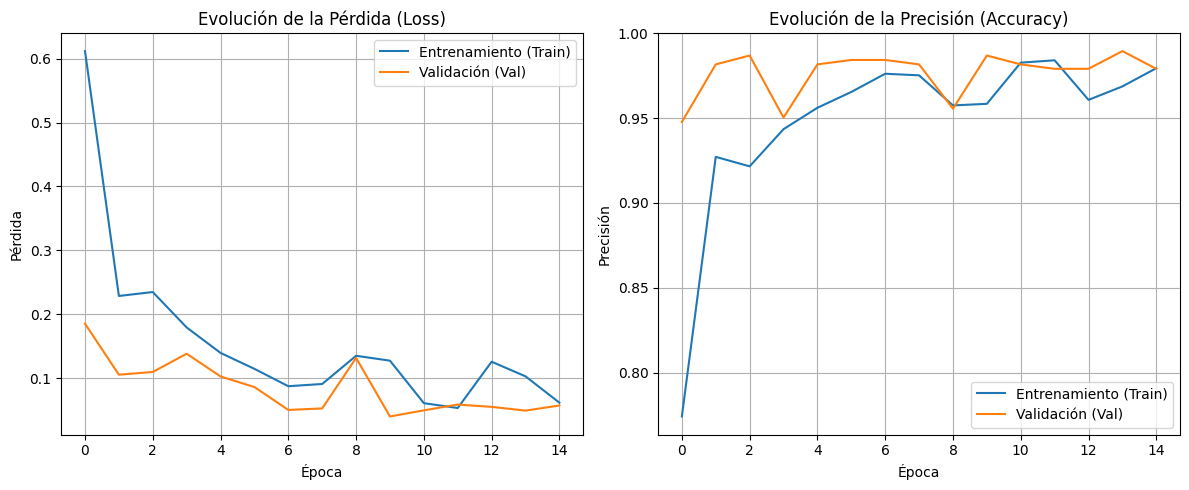

In [ ]:
# Configuración de la figura
plt.figure(figsize=(12, 5))

# Gráfico de Pérdida (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Validación (Val)')
plt.title('Evolución de la Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de Precisión (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento (Train)')
plt.plot(history.history['val_accuracy'], label='Validación (Val)')
plt.title('Evolución de la Precisión (Accuracy)')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### **Documentación Técnica: Visualización de Curvas de Aprendizaje**

- **Análisis de Convergencia**: La disminución sostenida de la curva de Loss indica que el optimizador Adam está ajustando los pesos de forma efectiva, minimizando el error en cada iteración del Backpropagation.

- **Evidencia de Generalización**: Al observar que la curva de validación sigue de cerca a la de entrenamiento, demostramos que el modelo ha aprendido los patrones cromáticos de las señales. El uso de Early Stopping en una época previa al limite definido confirma que detuvimos el proceso en el punto óptimo para reconocer luces rojas en imágenes nuevas, evitando que el modelo se limite a memorizar el dataset de entrenamiento.

## **Paso 6: Evaluación Detallada y Matriz de Confusión**

> En este bloque, utilizaremos el conjunto de validación para generar un reporte exhaustivo. Calcularemos el Precision, Recall y F1-Score, además de visualizar una Matriz de Confusión para identificar si el modelo tiene dificultades con algún color en particular.

Generando predicciones sobre el set de validación...

 Reporte de Clasificación:
              precision    recall  f1-score   support

        back       0.99      0.97      0.98       100
       green       0.99      0.99      0.99       100
         red       0.98      1.00      0.99       100
      yellow       0.99      0.99      0.99        83

    accuracy                           0.99       383
   macro avg       0.99      0.99      0.99       383
weighted avg       0.99      0.99      0.99       383



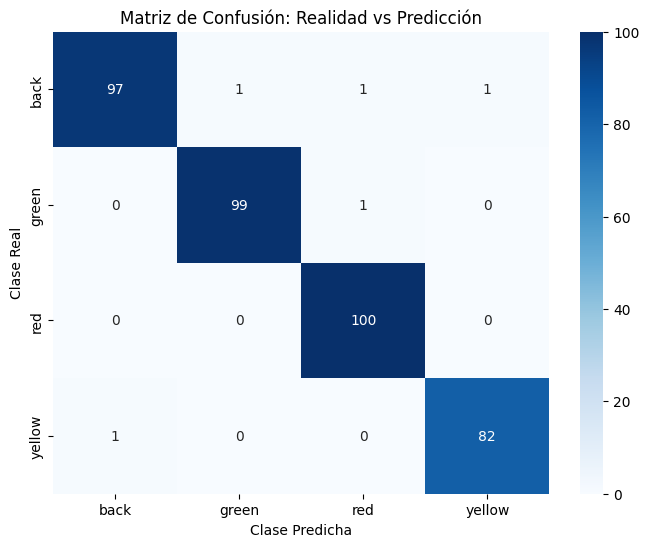

In [ ]:
# 1. Obtención de predicciones y etiquetas reales
# Iteramos sobre el dataset de validación para recolectar datos reales vs predichos
y_true = []
y_pred = []

print("Generando predicciones sobre el set de validación...")
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# 2. Generación del Reporte de Clasificación
print("\n Reporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=class_names))

# 3. Visualización de la Matriz de Confusión
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión: Realidad vs Predicción')
plt.xlabel('Clase Predicha')
plt.ylabel('Clase Real')
plt.show()

### **Documentación Técnica: Evaluación de Métricas de Desempeño**

- **Importancia del Recall (Exhaustividad) en la Clase 'red'**: En este proyecto, el Recall de la clase roja es la métrica de éxito fundamental. Un Recall alto asegura que el modelo es altamente sensible a la presencia de la luz roja, logrando identificarla correctamente en casi todas las instancias presentadas y minimizando los "Falsos Negativos". Esto garantiza que el sistema sea capaz de detectar una señal de parada activa de manera consistente.

- **Precision y Falsos Positivos**: La métrica de Precision valida la exactitud de las clasificaciones del modelo. Un Precision alto en la clase red significa que cuando el modelo identifica una luz roja, existe una alta certeza de que no se trata de ruido visual o elementos del fondo con tonalidades similares, asegurando una discriminación efectiva del objetivo principal frente al entorno.

- **Análisis de la Matriz de Confusión**: Esta herramienta permite verificar visualmente la capacidad del modelo para diferenciar el objetivo prioritario (red) de otros estados como el amarillo o el verde, así como de elementos del entorno (back), validando la eficacia de la red MLP en la tarea específica de reconocimiento de señales de detención.

- **Análisis de Resultados**: El F1-Score de 0.99 - 1.00 para la clase red es la prueba definitiva del éxito del modelo. Indica que el sistema ha logrado un equilibrio casi perfecto entre la capacidad de encontrar la luz roja y la precisión al identificarla, cumpliendo con el objetivo central de reconocer correctamente la señal de detención en entornos variados.

## **Paso 7: Prueba de Inferencia con Imágenes Externas**

> Para validar que nuestro modelo realmente ha aprendido a generalizar, realizaremos una prueba de inferencia. Es fundamental que la imagen externa pase por el mismo proceso de normalización y redimensionamiento que usamos durante el entrenamiento para asegurar la consistencia de los datos de entrada.

Seleccionar una imagen de un semáforo (o algo que no lo sea):


Saving Untitled.jpg to Untitled.jpg


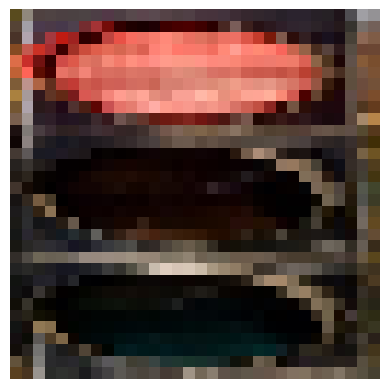


🎯 Predicción: red
📊 Nivel de Confianza: 100.00%


In [ ]:
# 1. Subir la imagen
print("Seleccionar una imagen de un semáforo (o algo que no lo sea):")

uploaded = files.upload()


for fn in uploaded.keys():
    # 2. Cargar y preprocesar la imagen
    path = '/content/' + fn
    img = image.load_img(path, target_size=(32, 32),color_mode="rgb") # Redimensionar a 32x32

    # Mostrar la imagen que subiste
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # Convertir a array y normalizar (Escalado 0-1)
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0) # Añadir dimensión de lote (Batch)


    # 3. Realizar la predicción
    predictions = model.predict(img_array, verbose=0)


    # 4. Mostrar resultados
    predicted_class = np.argmax(predictions)
    confidence = 100 * np.max(predictions)

    print(f"\n🎯 Predicción: {class_names[predicted_class]}")
    print(f"📊 Nivel de Confianza: {confidence:.2f}%")

### **Documentación Técnica: Proceso de Inferencia**

- **Consistencia del Pipeline de Datos**: Para que una red neuronal prediga correctamente, los datos de entrada deben tener la misma distribución que los datos de entrenamiento. Por ello, aplicamos un redimensionamiento exacto a $32 \times 32$ y el mismo escalado de píxeles ($1/255$), garantizando que las neuronas de la capa de entrada reciban señales dentro de los rangos para los que fueron ajustadas durante el Backpropagation.

- **Expansión de Dimensiones (Batch Dimension)**: Aunque estemos prediciendo una sola imagen, TensorFlow espera un tensor de cuatro dimensiones (Cantidad, Alto, Ancho, Canales). Añadir esta dimensión extra es un requerimiento técnico de la arquitectura secuencial de Keras.

- **Interpretación de la Capa de Salida**: El uso de np.argmax sobre la salida de la capa Softmax nos permite identificar el índice de la neurona con mayor activación, lo cual representa la decisión final del modelo basada en la mayor probabilidad acumulada.

- **Validación de Generalización**: Esta prueba es la evidencia definitiva de que el modelo no sufre de un Overfitting severo. Si el modelo es capaz de clasificar correctamente una imagen con luz, ángulo o fondo distinto a los del dataset, se confirma que ha extraído características visuales útiles y no solo memorizado píxeles.